# PRÁCTICA EVOLUCIÓN DIFERENCIAL

In [15]:
import math
import random 
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

#Leemos el archivo de datos 
path = "data.xlsx"
data = pd.read_excel(path, header=None,skiprows=1)
y = data[0].tolist()
x = data[1].tolist()

In [16]:


#-------------------FUNCIONES-------------------

#Función Objetivo
def fun_obj(a,x):
    return a[0] + a[1]*x + a[2]*x**2 + a[3]*x**3 + a[4]*x**4 + a[5]*x**5

def ECM(y,x,a):
    N = len(y)
    suma = 0
    for i in range(N):
        suma += (y[i] - fun_obj(a,x[i]))**2
    return suma * (1/N)
    
#Función para inicializar la población

def ini_pob(tam_pob,Imin,Imax):
    pob = []
    for i in range(tam_pob):
        individuo = []
        for j in range(6):
            individuo.append(random.uniform(Imin,Imax))
        pob.append(individuo)
    return pob

#Función para evaluar la población
def evaluar(pob,x_data,y_data):
    fitness = []
    for i in pob:
        eval = ECM(y_data,x_data,i)
        fitness.append(eval)
    return fitness

#Función para construir los valores mutantes
def mutar(individuo,pob,F):
    n = len(pob)
    indices = list(range(n))
    indices.remove(individuo)
    r1 = random.choice(indices)
    indices.remove(r1)
    r2 = random.choice(indices)
    indices.remove(r2)
    r3 = random.choice(indices)
    vector_mutante = []
    for j in range(6):
        vector_mutante.append(pob[r1][j]+(F*(pob[r2][j]-pob[r3][j])))
    return vector_mutante

#Funcion de cruza
def cruza(vector_mutante,individuo,CR):
    vector_prueba = []
    n = len(individuo)
    j_rand = random.randint(0,n-1)
    for j in range(n):
        if (random.random()<CR or j==j_rand):
            vector_prueba.append(vector_mutante[j])
        else:
            vector_prueba.append(individuo[j])
    return vector_prueba

#FUNCIÓN PARA SELECCIONAR INDIVIDUOS
def seleccion(individuo,vector_prueba,x_data,y_data):
    f1 = ECM(individuo,x_data,y_data)
    f2 = ECM(vector_prueba,x_data,y_data)
    if (f2<f1):
        return vector_prueba
    else:
        return individuo
    
#-------------------IMPLEMENTACIÓN-------------------
tam_pob = 100
Imin, Imax= -10,10
F = 0.8
CR = 0.9
generaciones = 1000


P = ini_pob(tam_pob,Imin,Imax)
historial_mse = []

for g in range(generaciones):
    nueva_poblacion = []
    for i in range(tam_pob):
        MUT = mutar(i,P,F)
        VEC_PRUEBA = cruza(MUT,P[i],CR)
        IND_NUEVO = seleccion(P[i],VEC_PRUEBA,x,y)
        nueva_poblacion.append(IND_NUEVO)
    P = nueva_poblacion
    mejor_mse = min(evaluar(P,x,y))
    historial_mse.append(mejor_mse)
    if g % 50 == 0:
        print(f"Generación {g} | Mejor MSE: {mejor_mse}")
    
#-------------------RESULTADOS-------------------
fitness = evaluar(P,x,y)
mejor_indice = fitness.index(min(fitness))
mejor_solucion = P[mejor_indice]
mejor_valor = fitness[mejor_indice]

print(f"\n Mejor Solución encontrada: {mejor_solucion}")

print(f"\n Mejor Valor de la función: {mejor_valor}")




Generación 0 | Mejor MSE: 5.6632313482260546e+19
Generación 50 | Mejor MSE: 4.7481039822780637e+30
Generación 100 | Mejor MSE: 2.284405245079012e+37
Generación 150 | Mejor MSE: 1.3043199745761944e+36
Generación 200 | Mejor MSE: 6.736004459588475e+35
Generación 250 | Mejor MSE: 3.434204194834556e+35
Generación 300 | Mejor MSE: 6.68990610504063e+32
Generación 350 | Mejor MSE: 1.4167131768603554e+30
Generación 400 | Mejor MSE: 2.949935062024677e+33
Generación 450 | Mejor MSE: 2.8280813908644936e+34
Generación 500 | Mejor MSE: 2.997828269678554e+34
Generación 550 | Mejor MSE: 3.0643780083861153e+34
Generación 600 | Mejor MSE: 3.070866312620134e+34
Generación 650 | Mejor MSE: 3.0719962808733994e+34
Generación 700 | Mejor MSE: 3.072137093932343e+34
Generación 750 | Mejor MSE: 3.072170790910232e+34
Generación 800 | Mejor MSE: 3.0721750770532614e+34
Generación 850 | Mejor MSE: 3.0721755912730773e+34
Generación 900 | Mejor MSE: 3.072175683453528e+34
Generación 950 | Mejor MSE: 3.072175699967635

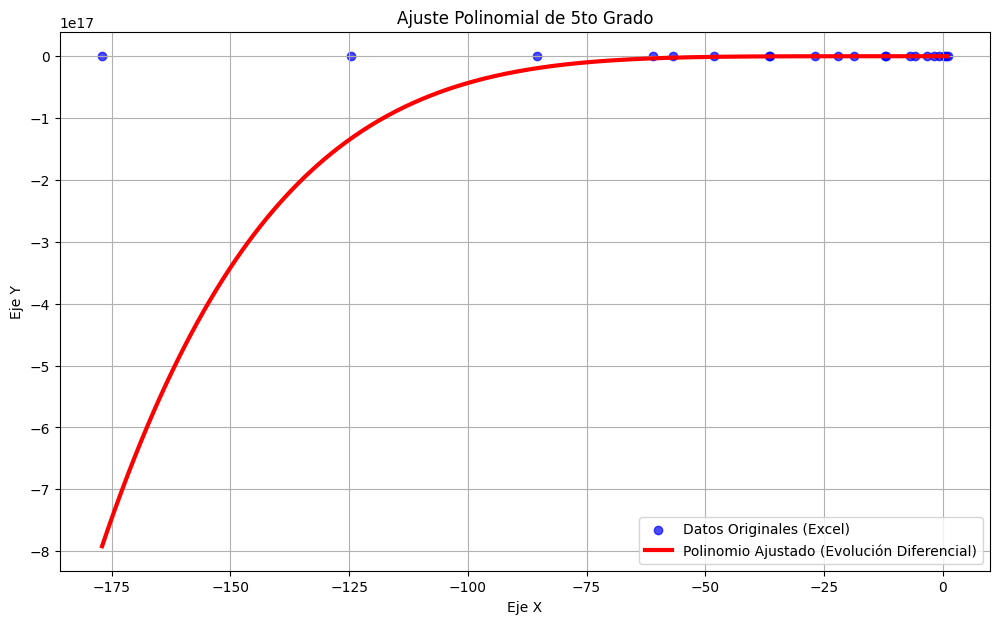

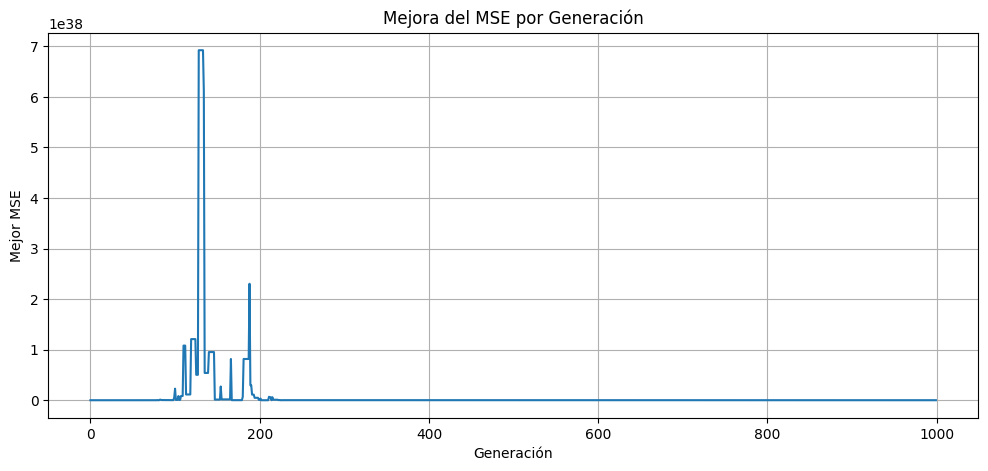

In [17]:
# Generar puntos (x) para la línea del polinomio
x_plot = np.linspace(min(x), max(x), 400)
# Calcular los valores (y) usando los coeficientes 'a' encontrados
y_plot = fun_obj(mejor_solucion, x_plot)

plt.figure(figsize=(12, 7))
# Graficar los datos originales del Excel
plt.scatter(x, y, label='Datos Originales (Excel)', alpha=0.7, color='blue')
# Graficar el polinomio que encontró el algoritmo
plt.plot(x_plot, y_plot, color='red', linewidth=3, label='Polinomio Ajustado (Evolución Diferencial)')
plt.title('Ajuste Polinomial de 5to Grado')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de cómo mejoró el MSE
plt.figure(figsize=(12, 5))
plt.plot(historial_mse)
plt.title('Mejora del MSE por Generación')
plt.xlabel('Generación')
plt.ylabel('Mejor MSE')
plt.grid(True)
plt.show()